# Deliverable 6b: 2.5D U-Net + Data Augmentation
## Benchmarking Noise-Robust Training Strategies for Liver Tumor Segmentation on LiTS

**Group:** 7 | **Members:** 26100098, 26100392  
**Improvement:** D6 (2.5D stacking) + **training-time data augmentation**  
**Reference results (all on full 51-volume data):**
- D3 baseline (Dice+CE, 2D):       Tumor 0.5011 @ epoch 8
- D4 Focal + class weights:        Tumor 0.4961 @ epoch 7
- D5 Curriculum sampling:          Tumor 0.4774 @ epoch 13
- **D6 2.5D U-Net:                  Tumor 0.5314 @ epoch 8**  ← we're stacking on top of this

**Goal:** Reduce overfitting by showing the network each slice in slightly different forms each epoch. The network can't memorize specific pixels because those pixels move/flip/change brightness every time.

**Augmentations applied at training time (NOT at validation):**
- Horizontal flip (p=0.5)
- Random rotation (±10°)
- Brightness jitter (±10%)
- Contrast jitter (±10%)

**Why this should work:** Every prior notebook showed severe overfitting (train loss 0.04, val loss 0.38 — 10× gap). Augmentation is the standard fix. Expected: +0.02 to +0.05 on tumor Dice, plus a smaller train/val gap in the curves.

## 1. Installs and Imports

In [11]:
import os, re, random, time, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

import nibabel as nib
from scipy import ndimage

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps'); print('Using MPS (M4 GPU)')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda'); print('Using CUDA')
else:
    DEVICE = torch.device('cpu');  print('Using CPU')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f'PyTorch: {torch.__version__}')

Using MPS (M4 GPU)
PyTorch: 2.11.0


## 2. Configuration

Identical to D6 plus new augmentation probabilities. Augmentation applies ONLY to training data; validation stays untouched so metrics are honest.

In [12]:
# CELL: Paths + hyperparameters — same as D6, plus augmentation knobs.
DATA_DIR = '/Users/aemanadnan/Desktop/DL proj/archive-2'

IMG_SIZE       = 128
BATCH_SIZE     = 16
NUM_EPOCHS     = 15
LR             = 1e-4
HU_MIN, HU_MAX = -100, 400
STACK_SIZE     = 3     # 2.5D — 3 adjacent slices

# augmentation hyperparameters ---
AUG_HFLIP_P    = 0.5    # prob. of horizontal flip
AUG_ROT_DEG    = 10.0   # max rotation angle (+/-)
AUG_ROT_P      = 0.5    # prob. of applying rotation
AUG_BRIGHT_P   = 0.5    # prob. of brightness shift
AUG_BRIGHT_MAG = 0.10   # max brightness shift as fraction of intensity
AUG_CONTRAST_P = 0.5    # prob. of contrast shift
AUG_CONTRAST_MAG = 0.10 # max contrast shift as fraction

print(f'Data: {DATA_DIR}')
print(f'Stack size: {STACK_SIZE} (2.5D)')
print(f'Augmentations:')
print(f'  HFlip:      p={AUG_HFLIP_P}')
print(f'  Rotation:   p={AUG_ROT_P},    +/-{AUG_ROT_DEG} deg')
print(f'  Brightness: p={AUG_BRIGHT_P}, +/-{AUG_BRIGHT_MAG*100:.0f}%')
print(f'  Contrast:   p={AUG_CONTRAST_P}, +/-{AUG_CONTRAST_MAG*100:.0f}%')

Data: /Users/aemanadnan/Desktop/DL proj/archive-2
Stack size: 3 (2.5D)
Augmentations:
  HFlip:      p=0.5
  Rotation:   p=0.5,    +/-10.0 deg
  Brightness: p=0.5, +/-10%
  Contrast:   p=0.5, +/-10%


## 3. Data Loading (unchanged from D6)

In [13]:
def load_lits_paths(data_dir):
    all_nii = glob.glob(os.path.join(data_dir, '**', '*.nii*'), recursive=True)
    vol_files = sorted(p for p in all_nii if 'volume'       in os.path.basename(p).lower())
    seg_files = sorted(p for p in all_nii if 'segmentation' in os.path.basename(p).lower())

    def case_id(path):
        m = re.search(r'(\d+)', os.path.basename(path))
        return int(m.group(1)) if m else None

    vol_map = {case_id(p): p for p in vol_files if case_id(p) is not None}
    seg_map = {case_id(p): p for p in seg_files if case_id(p) is not None}
    common  = sorted(set(vol_map).intersection(seg_map))

    if len(common) == 0:
        raise FileNotFoundError(f'No matched pairs under {data_dir}')

    vol_paths = [vol_map[i] for i in common]
    seg_paths = [seg_map[i] for i in common]
    print(f'Matched {len(vol_paths)} volume-segmentation pairs')
    return vol_paths, seg_paths


volume_paths, seg_paths = load_lits_paths(DATA_DIR)

Matched 51 volume-segmentation pairs


In [14]:
np.random.seed(SEED)
n       = len(volume_paths)
indices = np.random.permutation(n)

train_idx = indices[:int(0.70 * n)]
val_idx   = indices[int(0.70 * n):int(0.85 * n)]
test_idx  = indices[int(0.85 * n):]

train_vol = [volume_paths[i] for i in train_idx]
train_seg = [seg_paths[i]    for i in train_idx]
val_vol   = [volume_paths[i] for i in val_idx]
val_seg   = [seg_paths[i]    for i in val_idx]
test_vol  = [volume_paths[i] for i in test_idx]
test_seg  = [seg_paths[i]    for i in test_idx]

print(f'Train: {len(train_vol)} volumes')
print(f'Val:   {len(val_vol)} volumes')
print(f'Test:  {len(test_vol)} volumes')

Train: 35 volumes
Val:   8 volumes
Test:  8 volumes


## 4. 2.5D Dataset Class — **WITH AUGMENTATION (the key change from D6)**

Two critical rules for medical image augmentation:

1. **Same transform must apply to ALL channels AND the mask.** If we flip the CT horizontally, we also flip the mask. Otherwise the mask no longer describes the image. We sample one random transform per sample and apply it consistently.

2. **Training-only.** Augmentation is controlled by a boolean `augment=True` flag set only for the training dataset. The val dataset is built with `augment=False` so validation measures real performance on unmodified data.

**The transforms:**
- **Horizontal flip** — medical imaging is not left/right symmetric (liver is on patient's right), but flipping teaches the network to not rely on absolute position.
- **Small rotation (±10°)** — simulates small variations in patient positioning in the scanner.
- **Brightness/contrast jitter** — simulates scanner variability (different hospitals, different machines).

**What we deliberately DON'T do:**
- **No vertical flip** — would flip head/feet orientation, which is anatomically wrong.
- **No large rotations** — tumors shouldn't appear "upside down."
- **No zoom/crop** — would change relative tumor sizes, interferes with metric evaluation.

In [ ]:
class LiTS25DDataset(Dataset):
    def __init__(self, volume_paths, seg_paths,
                 img_size=128, hu_min=-100, hu_max=400,
                 stack_size=3, filter_background=True,
                 augment=False):
        assert stack_size % 2 == 1
        self.img_size   = img_size
        self.hu_min     = hu_min
        self.hu_max     = hu_max
        self.stack_size = stack_size
        self.half       = stack_size // 2
        self.augment    = augment     
        self.slices     = []
        self._vol_cache = {}
        self._seg_cache = {}

        print(f'Indexing slices (augment={augment})...')
        for vol_path, seg_path in zip(volume_paths, seg_paths):
            seg = nib.load(seg_path).get_fdata().astype(np.uint8)
            n_slices = seg.shape[2]
            for s in range(n_slices):
                if filter_background and not np.any(seg[:, :, s] > 0):
                    continue
                self.slices.append((vol_path, seg_path, s, n_slices))
        print(f'Total usable slices: {len(self.slices)}')

    def _get_vol(self, path):
        if path not in self._vol_cache:
            self._vol_cache[path] = nib.load(path).get_fdata().astype(np.float32)
        return self._vol_cache[path]

    def _get_seg(self, path):
        if path not in self._seg_cache:
            self._seg_cache[path] = nib.load(path).get_fdata().astype(np.uint8)
        return self._seg_cache[path]

    def _process_ct_slice(self, slice_2d):
        x = np.clip(slice_2d, self.hu_min, self.hu_max)
        x = (x - self.hu_min) / (self.hu_max - self.hu_min)
        h, w = x.shape
        return ndimage.zoom(x, (self.img_size / h, self.img_size / w), order=1).astype(np.float32)

    def _process_seg_slice(self, slice_2d):
        h, w = slice_2d.shape
        return ndimage.zoom(slice_2d, (self.img_size / h, self.img_size / w), order=0)

    def _augment_sample(self, ct_stack, seg):
        """
        Apply identical geometric transforms to all CT channels AND the seg mask.
        Intensity transforms apply only to CT (not the mask — mask values are class labels, not intensities).
        """
        #horizontal flip ---
        if random.random() < AUG_HFLIP_P:
            ct_stack = ct_stack[:, ::-1, :].copy()
            seg      = seg[::-1, :].copy()

        #small rotation ---
        if random.random() < AUG_ROT_P:
            angle = random.uniform(-AUG_ROT_DEG, AUG_ROT_DEG)
            # rotate each CT channel with bilinear (order=1)
            ct_stack = np.stack([
                ndimage.rotate(ct_stack[c], angle, reshape=False, order=1, mode='reflect')
                for c in range(ct_stack.shape[0])
            ], axis=0).astype(np.float32)
            # rotate mask with nearest-neighbor (order=0) so class labels stay integers
            seg = ndimage.rotate(seg.astype(np.float32), angle, reshape=False,
                                  order=0, mode='constant', cval=0).astype(np.int64)

        # brightness shift (additive) ---
        if random.random() < AUG_BRIGHT_P:
            shift = random.uniform(-AUG_BRIGHT_MAG, AUG_BRIGHT_MAG)
            ct_stack = np.clip(ct_stack + shift, 0.0, 1.0)

        # contrast shift (multiplicative around 0.5) ---
        if random.random() < AUG_CONTRAST_P:
            factor = 1.0 + random.uniform(-AUG_CONTRAST_MAG, AUG_CONTRAST_MAG)
            ct_stack = np.clip((ct_stack - 0.5) * factor + 0.5, 0.0, 1.0)

        return ct_stack.astype(np.float32), seg.astype(np.int64)

    def __len__(self):
        return len(self.slices)

    def __getitem__(self, idx):
        vol_path, seg_path, s, n_slices = self.slices[idx]
        vol = self._get_vol(vol_path)
        seg = self._get_seg(seg_path)

        stack_idxs = [max(0, min(n_slices - 1, s + offset))
                      for offset in range(-self.half, self.half + 1)]
        ct_channels = [self._process_ct_slice(vol[:, :, i]) for i in stack_idxs]
        ct_stack    = np.stack(ct_channels, axis=0)   

        seg_slice = seg[:, :, s].astype(np.int64)
        seg_slice = self._process_seg_slice(seg_slice)

        if self.augment:
            ct_stack, seg_slice = self._augment_sample(ct_stack, seg_slice)

        ct_tensor  = torch.from_numpy(ct_stack)
        seg_tensor = torch.from_numpy(seg_slice.astype(np.int64))
        return ct_tensor, seg_tensor

In [16]:
print('Building train dataset (WITH augmentation)...')
train_dataset = LiTS25DDataset(train_vol, train_seg, img_size=IMG_SIZE,
                                stack_size=STACK_SIZE, augment=True)   # <-- augment=True
print()
print('Building val dataset (NO augmentation)...')
val_dataset = LiTS25DDataset(val_vol, val_seg, img_size=IMG_SIZE,
                              stack_size=STACK_SIZE, augment=False)    # <-- augment=False

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)

print(f'\nTrain batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Building train dataset (WITH augmentation)...
Indexing slices (augment=True)...
Total usable slices: 4614

Building val dataset (NO augmentation)...
Indexing slices (augment=False)...
Total usable slices: 1116

Train batches: 289 | Val batches: 70


## 5. Sanity Check — Visualize Augmented Samples

Using sample idx=159 for augmentation check


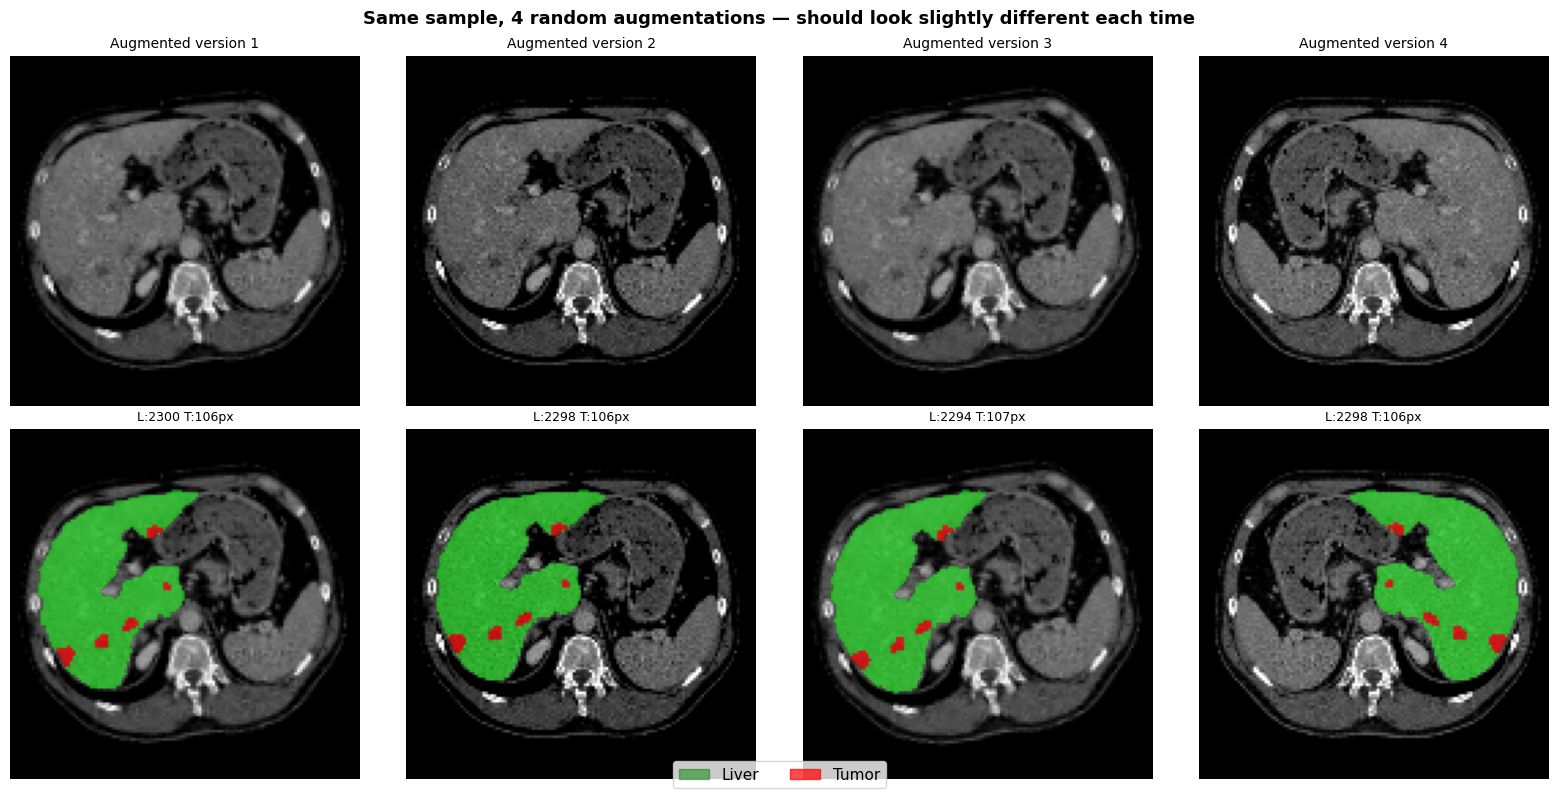

In [ ]:
target_idx = None
for i, (_, _, s, _) in enumerate(train_dataset.slices):
    _, seg_t = train_dataset[i]
    if (seg_t == 2).sum() > 100:
        target_idx = i
        break
if target_idx is None:
    target_idx = 0
print(f'Using sample idx={target_idx} for augmentation check')

samples = [train_dataset[target_idx] for _ in range(4)]

mid = STACK_SIZE // 2
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for col, (ct_t, seg_t) in enumerate(samples):
    ct   = ct_t[mid].numpy()
    mask = seg_t.numpy()
    axes[0, col].imshow(ct.T, cmap='gray', origin='lower')
    axes[0, col].set_title(f'Augmented version {col+1}', fontsize=10)
    axes[0, col].axis('off')

    overlay = np.zeros((*ct.shape, 4))
    overlay[mask == 1] = [0, 1, 0, 0.5]
    overlay[mask == 2] = [1, 0, 0, 0.7]
    axes[1, col].imshow(ct.T, cmap='gray', origin='lower')
    axes[1, col].imshow(overlay.transpose(1, 0, 2), origin='lower')
    axes[1, col].set_title(f'L:{(mask==1).sum()} T:{(mask==2).sum()}px', fontsize=9)
    axes[1, col].axis('off')

green_patch = mpatches.Patch(color='green', alpha=0.5, label='Liver')
red_patch   = mpatches.Patch(color='red',   alpha=0.7, label='Tumor')
fig.legend(handles=[green_patch, red_patch], loc='lower center', ncol=2, fontsize=11)
plt.suptitle('Same sample, 4 random augmentations — should look slightly different each time',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. 2D U-Net with 3 Input Channels (unchanged from D6)

In [18]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)


class UNet2D(nn.Module):
    def __init__(self, in_channels=3, num_classes=3, base_features=64):
        super().__init__()
        f = base_features
        self.enc1 = ConvBlock(in_channels, f)
        self.enc2 = ConvBlock(f,    f*2)
        self.enc3 = ConvBlock(f*2,  f*4)
        self.enc4 = ConvBlock(f*4,  f*8)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(f*8, f*16)
        self.up4  = nn.ConvTranspose2d(f*16, f*8, kernel_size=2, stride=2)
        self.dec4 = ConvBlock(f*16, f*8)
        self.up3  = nn.ConvTranspose2d(f*8,  f*4, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(f*8,  f*4)
        self.up2  = nn.ConvTranspose2d(f*4,  f*2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(f*4,  f*2)
        self.up1  = nn.ConvTranspose2d(f*2,  f,   kernel_size=2, stride=2)
        self.dec1 = ConvBlock(f*2,  f)
        self.out_conv = nn.Conv2d(f, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)


model = UNet2D(in_channels=STACK_SIZE, num_classes=3, base_features=64).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {total_params:,}')

Model parameters: 31,037,763


## 7. Loss and Metric (unchanged — Dice + CE)

In [19]:
def dice_loss(preds, targets, num_classes=3, smooth=1e-6):
    preds_soft      = F.softmax(preds, dim=1)
    targets_one_hot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()
    dims            = (0, 2, 3)
    intersection    = (preds_soft * targets_one_hot).sum(dims)
    cardinality     = (preds_soft + targets_one_hot).sum(dims)
    dice_per_class  = (2.0 * intersection + smooth) / (cardinality + smooth)
    return 1.0 - dice_per_class.mean()


ce_fn = nn.CrossEntropyLoss()

def combined_loss(preds, targets):
    return dice_loss(preds, targets) + ce_fn(preds, targets)


def compute_dice_per_class(preds, targets, num_classes=3, smooth=1e-6):
    pred_classes = preds.argmax(dim=1)
    scores = []
    for c in range(num_classes):
        p = (pred_classes == c).float()
        t = (targets      == c).float()
        inter = (p * t).sum()
        denom = p.sum() + t.sum()
        score = ((2.0 * inter + smooth) / (denom + smooth)).item() if denom > 0 else 1.0
        scores.append(score)
    return scores


print('Loss: Dice + CrossEntropy')
print('Metric: Per-class Dice')

Loss: Dice + CrossEntropy
Metric: Per-class Dice


## 8. Training

Same training loop as D6. The augmentation is already baked into the train DataLoader (via `augment=True`), so each batch arrives pre-augmented.

In [20]:
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=4, factor=0.5
)

history = {
    'train_loss':     [],
    'val_loss':       [],
    'val_liver_dice': [],
    'val_tumor_dice': []
}

best_tumor_dice  = 0.0
best_model_state = None

print('=' * 70)
print('TRAINING — D6b: 2.5D U-Net + Data Augmentation')
print(f'Epochs: {NUM_EPOCHS} | Batch: {BATCH_SIZE} | Device: {DEVICE}')
print(f'Input: {STACK_SIZE}-slice stack | Loss: Dice + CrossEntropy')
print(f'Augmentations: hflip, rot+/-{AUG_ROT_DEG}, brightness+/-{AUG_BRIGHT_MAG}, contrast+/-{AUG_CONTRAST_MAG}')
print(f'Train batches/epoch: {len(train_loader)}')
print('=' * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    model.train()
    train_losses = []

    for batch_idx, (ct_batch, seg_batch) in enumerate(train_loader):
        ct_batch  = ct_batch.to(DEVICE)
        seg_batch = seg_batch.to(DEVICE)

        optimizer.zero_grad()
        preds = model(ct_batch)
        loss  = combined_loss(preds, seg_batch)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        if (batch_idx + 1) % 100 == 0:
            elapsed  = time.time() - epoch_start
            eta_mins = (elapsed / (batch_idx + 1)) * (len(train_loader) - batch_idx - 1) / 60
            print(f'  Ep {epoch:02d} | Batch {batch_idx+1}/{len(train_loader)} '
                  f'| Loss: {loss.item():.4f} | ETA: {eta_mins:.1f}min')

    model.eval()
    val_losses, liver_dices, tumor_dices = [], [], []
    with torch.no_grad():
        for ct_batch, seg_batch in val_loader:
            ct_batch  = ct_batch.to(DEVICE)
            seg_batch = seg_batch.to(DEVICE)
            preds     = model(ct_batch)
            val_losses.append(combined_loss(preds, seg_batch).item())
            scores = compute_dice_per_class(preds, seg_batch)
            liver_dices.append(scores[1])
            tumor_dices.append(scores[2])

    mean_train = np.mean(train_losses)
    mean_val   = np.mean(val_losses)
    mean_liver = np.mean(liver_dices)
    mean_tumor = np.mean(tumor_dices)

    history['train_loss'].append(mean_train)
    history['val_loss'].append(mean_val)
    history['val_liver_dice'].append(mean_liver)
    history['val_tumor_dice'].append(mean_tumor)

    scheduler.step(mean_tumor)
    if mean_tumor > best_tumor_dice:
        best_tumor_dice = mean_tumor
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    epoch_mins = (time.time() - epoch_start) / 60
    flag = ' *** BEST' if mean_tumor == best_tumor_dice else ''
    print(f'\nEpoch {epoch:02d}/{NUM_EPOCHS} | {epoch_mins:.1f}min | '
          f'Train: {mean_train:.4f} | Val: {mean_val:.4f} | '
          f'Liver: {mean_liver:.4f} | Tumor: {mean_tumor:.4f}{flag}\n')

model.load_state_dict(best_model_state)
torch.save(best_model_state, 'best_unet_d6b_25d_aug.pth')
print(f'Best model saved. Best Tumor Dice: {best_tumor_dice:.4f}')

TRAINING — D6b: 2.5D U-Net + Data Augmentation
Epochs: 15 | Batch: 16 | Device: mps
Input: 3-slice stack | Loss: Dice + CrossEntropy
Augmentations: hflip, rot+/-10.0, brightness+/-0.1, contrast+/-0.1
Train batches/epoch: 289
  Ep 01 | Batch 100/289 | Loss: 0.8932 | ETA: 5.6min
  Ep 01 | Batch 200/289 | Loss: 0.7481 | ETA: 2.2min

Epoch 01/15 | 7.1min | Train: 0.8998 | Val: 0.7280 | Liver: 0.7692 | Tumor: 0.5429 *** BEST

  Ep 02 | Batch 100/289 | Loss: 0.5562 | ETA: 3.6min
  Ep 02 | Batch 200/289 | Loss: 0.5114 | ETA: 1.7min

Epoch 02/15 | 5.8min | Train: 0.5556 | Val: 0.5416 | Liver: 0.8397 | Tumor: 0.2860

  Ep 03 | Batch 100/289 | Loss: 0.4585 | ETA: 3.5min
  Ep 03 | Batch 200/289 | Loss: 0.3397 | ETA: 1.7min

Epoch 03/15 | 5.8min | Train: 0.4204 | Val: 0.4761 | Liver: 0.8443 | Tumor: 0.4578

  Ep 04 | Batch 100/289 | Loss: 0.3152 | ETA: 3.5min
  Ep 04 | Batch 200/289 | Loss: 0.2668 | ETA: 1.7min

Epoch 04/15 | 5.8min | Train: 0.3277 | Val: 0.5464 | Liver: 0.7455 | Tumor: 0.1659

  

## 9. Results Summary

In [21]:
best_liver = max(history['val_liver_dice'])
best_tumor = max(history['val_tumor_dice'])
best_epoch = int(np.argmax(history['val_tumor_dice']) + 1)

D3_LIVER, D3_TUMOR, D3_EPOCH = 0.8885, 0.5011, 8
D4_LIVER, D4_TUMOR, D4_EPOCH = 0.8901, 0.4961, 7
D5_LIVER, D5_TUMOR, D5_EPOCH = 0.8886, 0.4774, 13
D6_LIVER, D6_TUMOR, D6_EPOCH = 0.8917, 0.5314, 8

liver_delta_d6 = best_liver - D6_LIVER
tumor_delta_d6 = best_tumor - D6_TUMOR
liver_delta_d3 = best_liver - D3_LIVER
tumor_delta_d3 = best_tumor - D3_TUMOR

print('=' * 90)
print('D6b RESULTS — 2.5D U-Net + Data Augmentation')
print('=' * 90)
print(f'Architecture:    2D U-Net, in_channels={STACK_SIZE} (2.5D) + training-time augmentation')
print(f'Image size:      {IMG_SIZE}x{IMG_SIZE}')
print(f'Epochs trained:  {NUM_EPOCHS}')
print(f'Best Epoch:      {best_epoch}')
print('-' * 90)
print(f'{"":22}{"D3":>10}{"D4":>10}{"D5":>10}{"D6":>10}{"D6b":>10}{"vs D6":>10}{"vs D3":>10}')
print(f'{"Liver Dice":22}{D3_LIVER:>10.4f}{D4_LIVER:>10.4f}{D5_LIVER:>10.4f}{D6_LIVER:>10.4f}'
      f'{best_liver:>10.4f}{liver_delta_d6:>+10.4f}{liver_delta_d3:>+10.4f}')
print(f'{"Tumor Dice":22}{D3_TUMOR:>10.4f}{D4_TUMOR:>10.4f}{D5_TUMOR:>10.4f}{D6_TUMOR:>10.4f}'
      f'{best_tumor:>10.4f}{tumor_delta_d6:>+10.4f}{tumor_delta_d3:>+10.4f}')
print(f'{"Best epoch":22}{D3_EPOCH:>10d}{D4_EPOCH:>10d}{D5_EPOCH:>10d}{D6_EPOCH:>10d}{best_epoch:>10d}')
print('=' * 90)
print()
print('Interpretation vs D6 (2.5D without augmentation):')
if tumor_delta_d6 > 0.02:
    print(f'  Tumor Dice improved by {tumor_delta_d6:+.4f} over D6 — augmentation helped.')
    print(f'  This supports the hypothesis that D6 was overfitting; augmentation reduced that.')
    #add attention if this works?
elif tumor_delta_d6 > -0.01:
    print(f'  Tumor Dice roughly matches D6 ({tumor_delta_d6:+.4f}).')
else:
    print(f'  Tumor Dice dropped by {tumor_delta_d6:+.4f} vs D6 — augmentation may be too aggressive.')
#reduce rot or brightness?  

D6b RESULTS — 2.5D U-Net + Data Augmentation
Architecture:    2D U-Net, in_channels=3 (2.5D) + training-time augmentation
Image size:      128x128
Epochs trained:  15
Best Epoch:      1
------------------------------------------------------------------------------------------
                              D3        D4        D5        D6       D6b     vs D6     vs D3
Liver Dice                0.8885    0.8901    0.8886    0.8917    0.8712   -0.0205   -0.0173
Tumor Dice                0.5011    0.4961    0.4774    0.5314    0.5429   +0.0115   +0.0418
Best epoch                     8         7        13         8         1

Interpretation vs D6 (2.5D without augmentation):
  Tumor Dice roughly matches D6 (+0.0115).


## 10. Training Curves

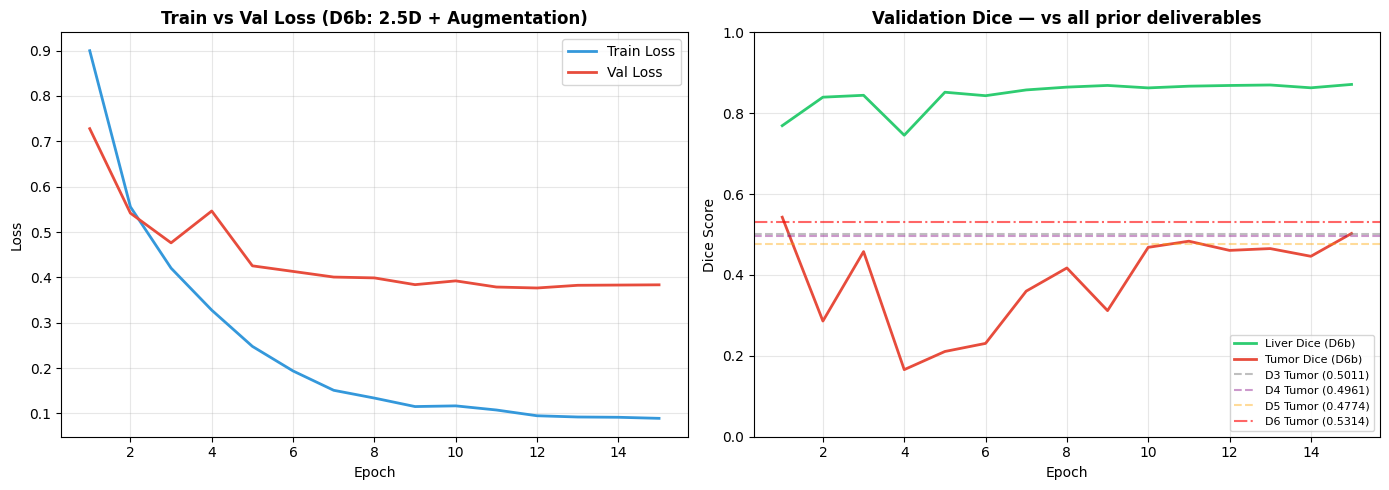

Saved: training_curves_d6b.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='#3498db', linewidth=2)
axes[0].plot(epochs, history['val_loss'],   label='Val Loss',   color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Train vs Val Loss (D6b: 2.5D + Augmentation)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['val_liver_dice'], label='Liver Dice (D6b)', color='#2ecc71', linewidth=2)
axes[1].plot(epochs, history['val_tumor_dice'], label='Tumor Dice (D6b)', color='#e74c3c', linewidth=2)
axes[1].axhline(y=0.5011, color='gray',   linestyle='--', alpha=0.5, label='D3 Tumor (0.5011)')
axes[1].axhline(y=0.4961, color='purple', linestyle='--', alpha=0.4, label='D4 Tumor (0.4961)')
axes[1].axhline(y=0.4774, color='orange', linestyle='--', alpha=0.4, label='D5 Tumor (0.4774)')
axes[1].axhline(y=0.5314, color='red',    linestyle='-.', alpha=0.6, label='D6 Tumor (0.5314)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice Score')
axes[1].set_title('Validation Dice — vs all prior deliverables', fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_d6b.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves_d6b.png')

## 11. Qualitative Predictions

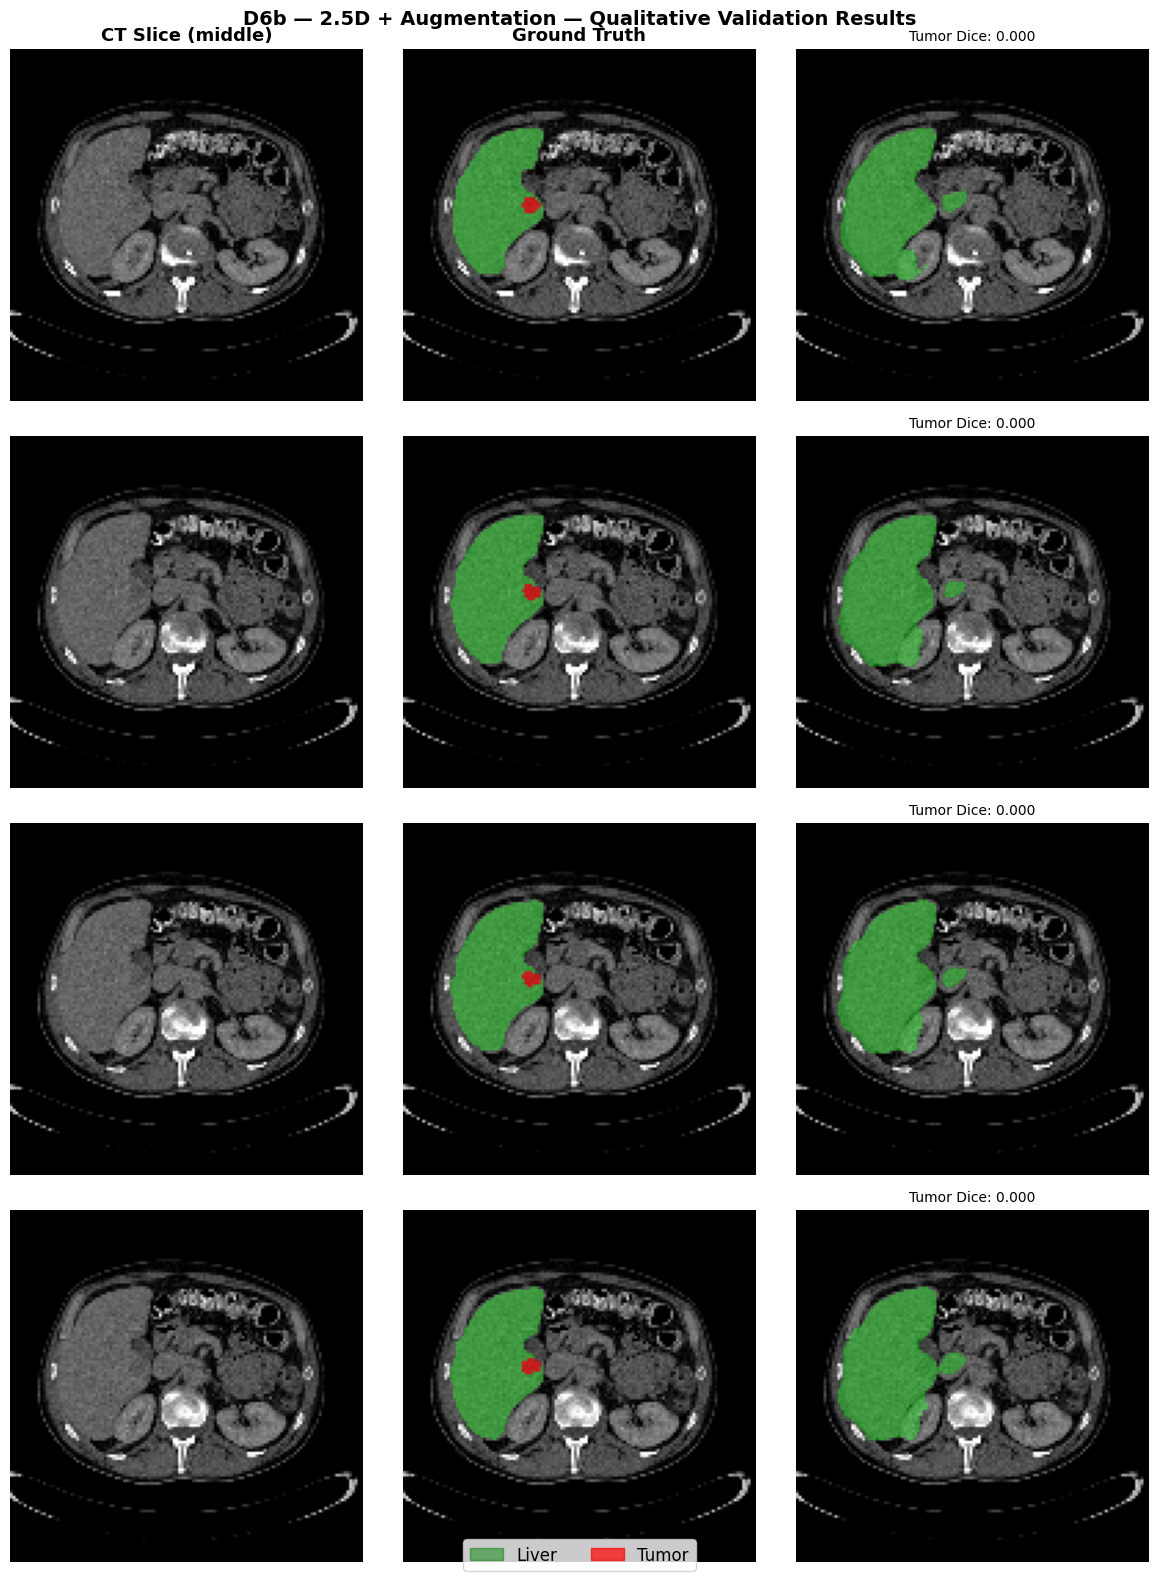

Saved: qualitative_d6b.png


In [ ]:
model.eval()
samples = []

with torch.no_grad():
    for ct_batch, seg_batch in val_loader:
        ct_batch  = ct_batch.to(DEVICE)
        seg_batch = seg_batch.to(DEVICE)
        preds     = model(ct_batch)
        pred_cls  = preds.argmax(dim=1)

        for i in range(ct_batch.shape[0]):
            gt = seg_batch[i].cpu().numpy()
            if np.sum(gt == 2) > 30:
                mid = STACK_SIZE // 2
                samples.append({
                    'ct':   ct_batch[i, mid].cpu().numpy(),
                    'gt':   gt,
                    'pred': pred_cls[i].cpu().numpy()
                })
        if len(samples) >= 4:
            break


def make_overlay(ct, seg):
    overlay = np.zeros((*ct.shape, 4))
    overlay[seg == 1] = [0, 1, 0, 0.35]
    overlay[seg == 2] = [1, 0, 0, 0.65]
    return overlay


n_show = min(4, len(samples))
fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show))
if n_show == 1: axes = [axes]

for col, title in enumerate(['CT Slice (middle)', 'Ground Truth', 'Prediction']):
    axes[0][col].set_title(title, fontsize=13, fontweight='bold')

for row, s in enumerate(samples[:n_show]):
    ct, gt, pred = s['ct'], s['gt'], s['pred']

    axes[row][0].imshow(ct.T, cmap='gray', origin='lower')
    axes[row][0].axis('off')

    axes[row][1].imshow(ct.T, cmap='gray', origin='lower')
    axes[row][1].imshow(make_overlay(ct, gt).transpose(1, 0, 2), origin='lower')
    axes[row][1].axis('off')

    axes[row][2].imshow(ct.T, cmap='gray', origin='lower')
    axes[row][2].imshow(make_overlay(ct, pred).transpose(1, 0, 2), origin='lower')

    p_t = (pred == 2).astype(float)
    g_t = (gt   == 2).astype(float)
    inter = (p_t * g_t).sum()
    denom = p_t.sum() + g_t.sum()
    sample_dice = (2 * inter / denom) if denom > 0 else 1.0
    axes[row][2].set_title(f'Tumor Dice: {sample_dice:.3f}', fontsize=10)
    axes[row][2].axis('off')

green_patch = mpatches.Patch(color='green', alpha=0.5, label='Liver')
red_patch   = mpatches.Patch(color='red',   alpha=0.7, label='Tumor')
fig.legend(handles=[green_patch, red_patch], loc='lower center', ncol=2, fontsize=12)
plt.suptitle('D6b — 2.5D + Augmentation — Qualitative Validation Results',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('qualitative_d6b.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: qualitative_d6b.png')